TUTORIAL: SELEÇÃO DE CARACTERÍSTICAS E t-SNE

1. EXPLORANDO O DATASET
--------------------------------------------------
Formato dos dados: (569, 30)
Número de características: 30
Classes: ['malignant' 'benign']

Primeiras 5 características: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']

2. SELEÇÃO POR FILTRO - MÉTODOS ESTATÍSTICOS
--------------------------------------------------

2.1 Filtro de Variância
Características originais: 30
Características após filtro de variância: 11
Removidas: 19

2.2 Seleção por F-Score (ANOVA)

2.3 Seleção por Informação Mútua

3. SELEÇÃO POR WRAPPER - RFE
--------------------------------------------------
Características selecionadas por RFE: 10
Top 5: ['mean radius' 'mean compactness' 'mean concavity' 'texture error'
 'worst radius']

3.2 RFE com Validação Cruzada (RFECV)
Número ótimo de características: 19
Score com características ótimas: 0.965


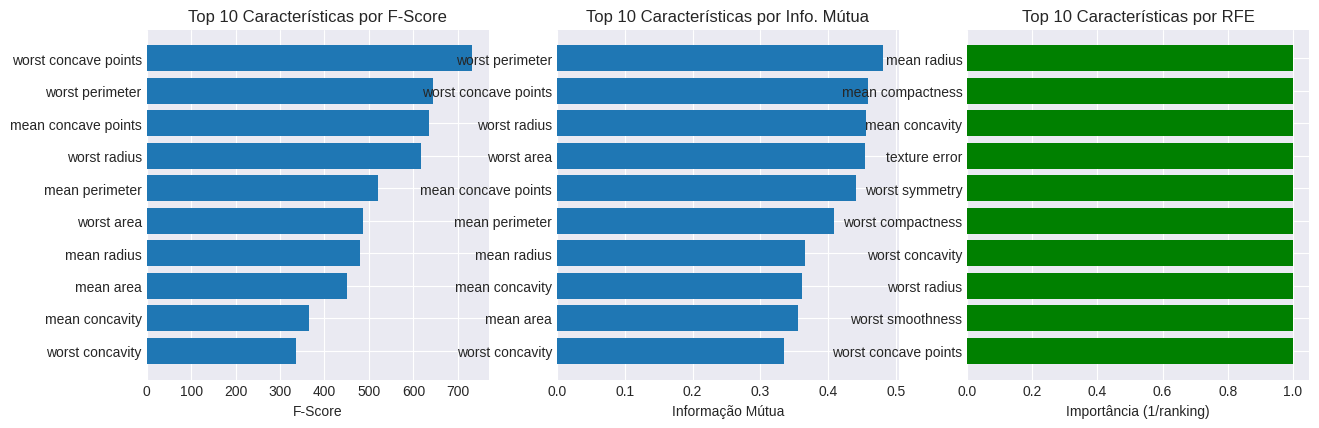

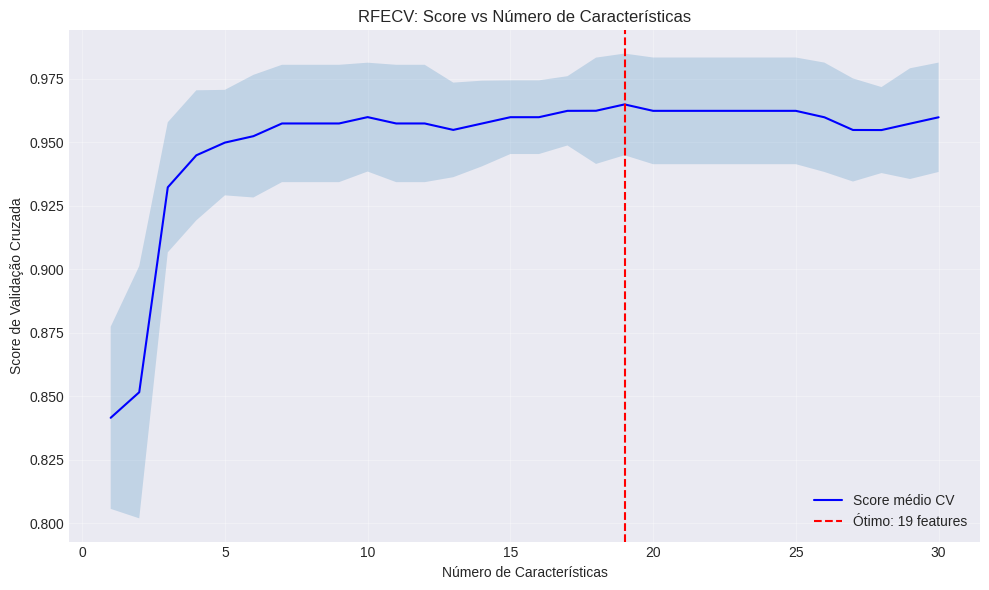


4. SELEÇÃO EMBEDDED - LASSO E RANDOM FOREST
--------------------------------------------------

4.1 LASSO - Características selecionadas: 9

5. COMPARANDO EFICÁCIA DOS MÉTODOS
--------------------------------------------------

Comparação de Métodos:
               method  n_features  mean_score  std_score
Todas características          30    0.959842   0.021526
              F-Score          10    0.947310   0.016461
     Informação Mútua          10    0.947310   0.016461
                  RFE          10    0.959905   0.021421
        Random Forest          10    0.947310   0.016461


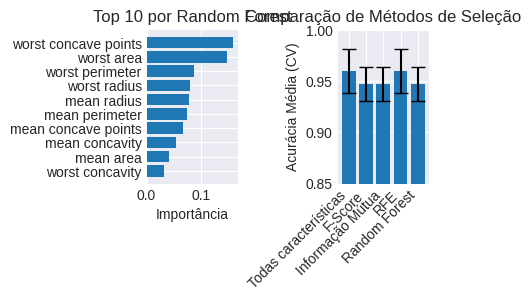


6. t-SNE - VISUALIZAÇÃO DE ALTA DIMENSIONALIDADE
--------------------------------------------------
Dataset de dígitos: (1797, 64)
Classes: [0 1 2 3 4 5 6 7 8 9]

Aplicando t-SNE com perplexidade=5...

Aplicando t-SNE com perplexidade=30...

Aplicando t-SNE com perplexidade=50...

7. COMPARANDO t-SNE COM PCA
--------------------------------------------------

8. UMAP - ALTERNATIVA MODERNA AO t-SNE
--------------------------------------------------
Aplicando UMAP com n_neighbors=5...
Aplicando UMAP com n_neighbors=15...


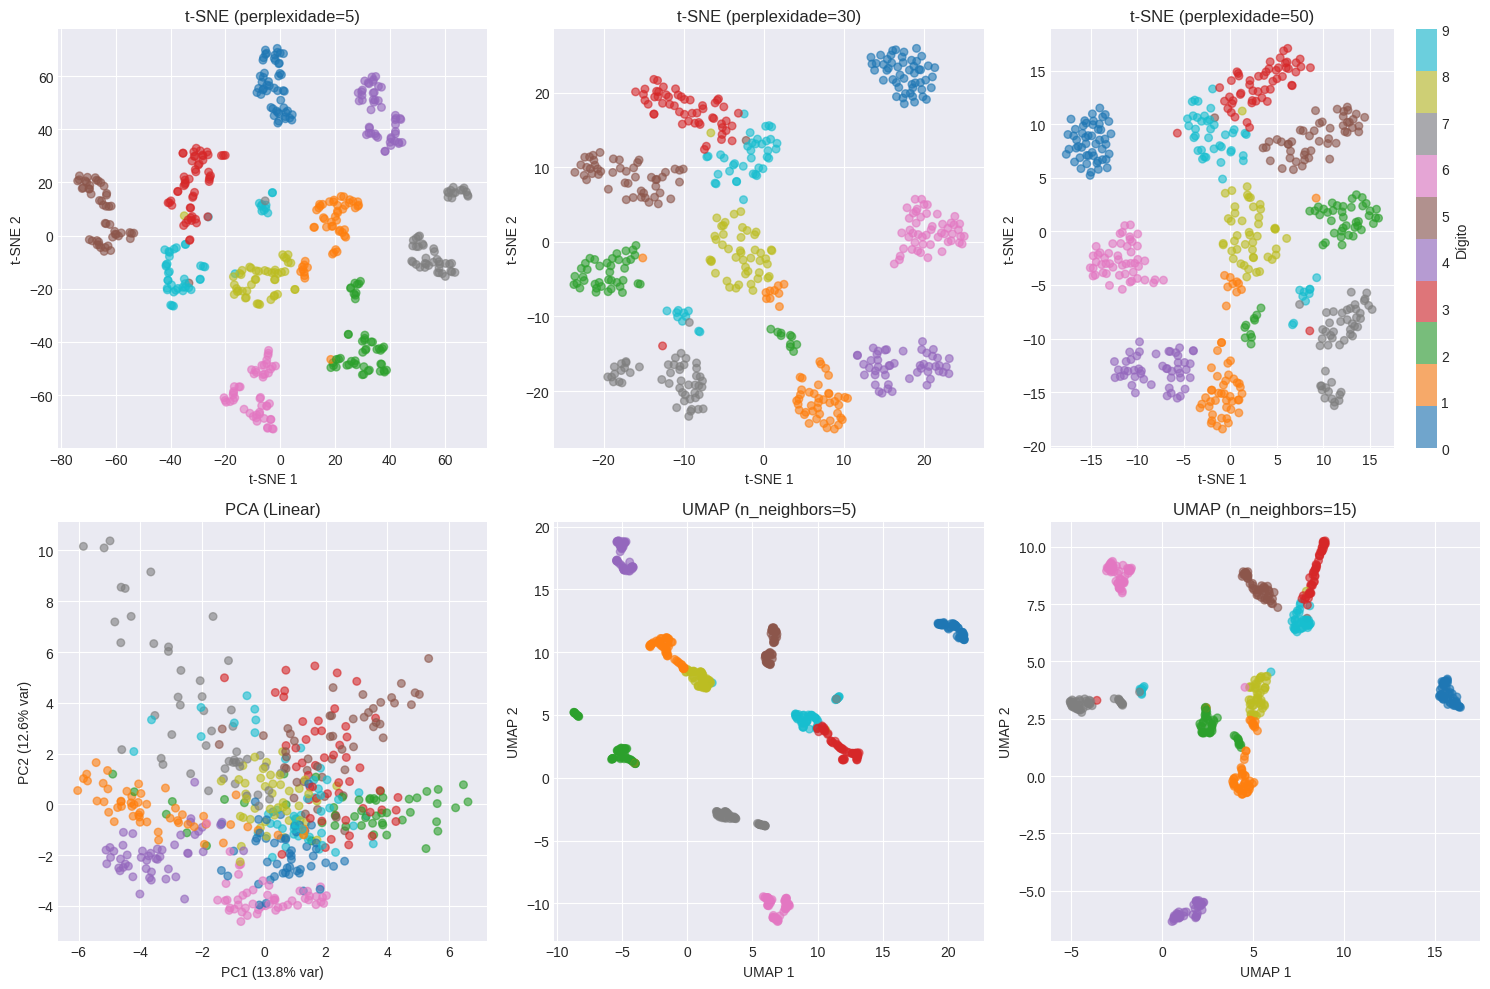


9. PIPELINE COMPLETO: SELEÇÃO → PCA → t-SNE/UMAP
--------------------------------------------------
Executando pipeline completo...
1. Características selecionadas: 15
2. Após PCA: 5 componentes


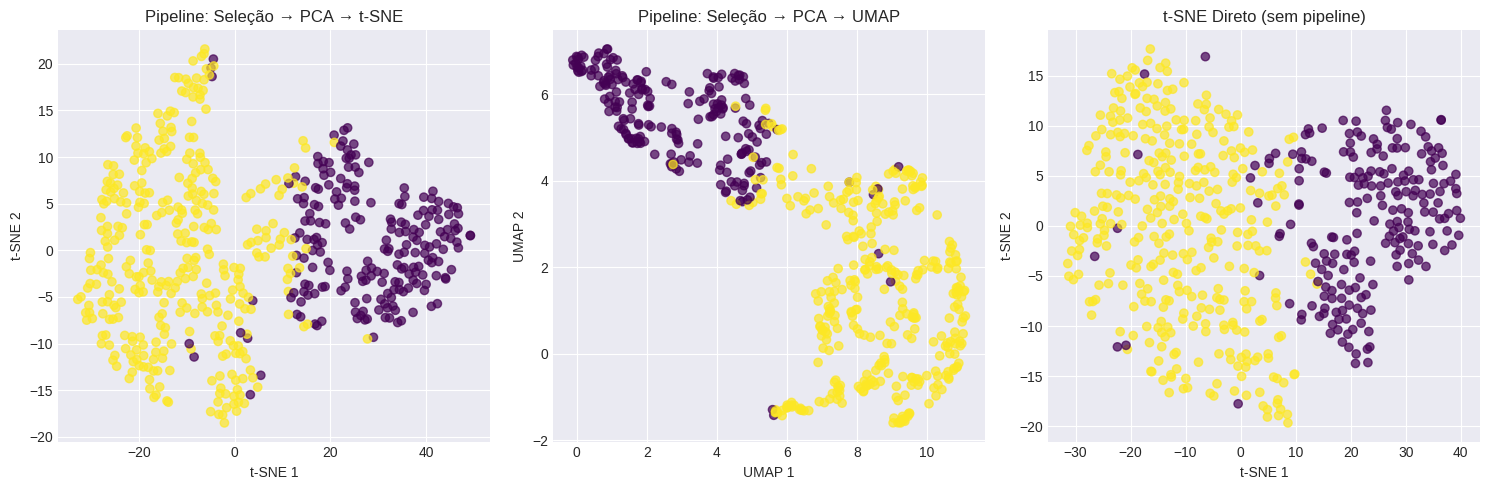


10. TÉCNICAS ESTADO DA ARTE
--------------------------------------------------

SHAP (SHapley Additive exPlanations) - Seleção Interpretável:
- Baseado em teoria dos jogos
- Fornece importância individual para cada predição
- Mais robusto que feature importance tradicional

Código exemplo (requer instalação: pip install shap):

# import shap
# explainer = shap.TreeExplainer(rf)
# shap_values = explainer.shap_values(X_test)
# shap.summary_plot(shap_values, X_test, feature_names=feature_names)


RESUMO: GUIA DE DECISÃO

SELEÇÃO DE CARACTERÍSTICAS:

1. FILTRO (Rápido, inicial):
   - F-Score: Relações lineares
   - Info. Mútua: Captura não-linearidades
   - Variância: Remove constantes

2. WRAPPER (Preciso, lento):
   - RFE: Ótimo para modelos lineares
   - RFECV: Com validação cruzada

3. EMBEDDED (Integrado):
   - LASSO: Seleção automática
   - Random Forest: Importância robusta
   - SHAP: Interpretabilidade máxima

VISUALIZAÇÃO:

1. PCA:
   - Rápido, preserva variância global
   - Bom 

In [2]:
# =============================================================================
# SELEÇÃO DE CARACTERÍSTICAS E t-SNE - TUTORIAL COMPLETO
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer, load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, Lasso
from sklearn.feature_selection import (
    SelectKBest, f_classif, mutual_info_classif,
    RFE, RFECV, SelectFromModel,
    chi2, VarianceThreshold
)
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Para técnicas estado da arte
# pip install umap-learn shap
import umap
# import shap  # Comentado para evitar problemas de instalação

# Configuração para gráficos
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

# =============================================================================
# PARTE 1: PREPARAÇÃO DOS DADOS
# =============================================================================

print("="*70)
print("TUTORIAL: SELEÇÃO DE CARACTERÍSTICAS E t-SNE")
print("="*70)

# Carregando dataset de câncer de mama para seleção de características
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names

# Criando DataFrame
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print("\n1. EXPLORANDO O DATASET")
print("-" * 50)
print(f"Formato dos dados: {X.shape}")
print(f"Número de características: {len(feature_names)}")
print(f"Classes: {data.target_names}")
print(f"\nPrimeiras 5 características: {feature_names[:5]}")

# Dividindo dados
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# =============================================================================
# PARTE 2: MÉTODOS DE FILTRO
# =============================================================================

print("\n2. SELEÇÃO POR FILTRO - MÉTODOS ESTATÍSTICOS")
print("-" * 50)

# 2.1 Removendo características com baixa variância
print("\n2.1 Filtro de Variância")
var_threshold = VarianceThreshold(threshold=0.1)
X_var = var_threshold.fit_transform(X_train)
features_kept_var = feature_names[var_threshold.get_support()]
print(f"Características originais: {X_train.shape[1]}")
print(f"Características após filtro de variância: {X_var.shape[1]}")
print(f"Removidas: {X_train.shape[1] - X_var.shape[1]}")

# 2.2 Seleção por F-score (ANOVA)
print("\n2.2 Seleção por F-Score (ANOVA)")
k_best = 10
selector_f = SelectKBest(score_func=f_classif, k=k_best)
X_f = selector_f.fit_transform(X_train, y_train)

# Visualizando scores
f_scores = selector_f.scores_
feature_scores_f = pd.DataFrame({
    'feature': feature_names,
    'f_score': f_scores
}).sort_values('f_score', ascending=False)

plt.figure(figsize=(15, 10))

# Plot 1: Top features por F-score
plt.subplot(2, 3, 1)
top_features_f = feature_scores_f.head(10)
plt.barh(range(len(top_features_f)), top_features_f['f_score'])
plt.yticks(range(len(top_features_f)), top_features_f['feature'])
plt.xlabel('F-Score')
plt.title('Top 10 Características por F-Score')
plt.gca().invert_yaxis()

# 2.3 Informação Mútua
print("\n2.3 Seleção por Informação Mútua")
selector_mi = SelectKBest(score_func=mutual_info_classif, k=k_best)
X_mi = selector_mi.fit_transform(X_train, y_train)

# Visualizando scores
mi_scores = selector_mi.scores_
feature_scores_mi = pd.DataFrame({
    'feature': feature_names,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False)

# Plot 2: Top features por Informação Mútua
plt.subplot(2, 3, 2)
top_features_mi = feature_scores_mi.head(10)
plt.barh(range(len(top_features_mi)), top_features_mi['mi_score'])
plt.yticks(range(len(top_features_mi)), top_features_mi['feature'])
plt.xlabel('Informação Mútua')
plt.title('Top 10 Características por Info. Mútua')
plt.gca().invert_yaxis()

# =============================================================================
# PARTE 3: MÉTODOS WRAPPER
# =============================================================================

print("\n3. SELEÇÃO POR WRAPPER - RFE")
print("-" * 50)

# 3.1 Recursive Feature Elimination (RFE)
estimator = LogisticRegression(max_iter=1000, random_state=42)
rfe = RFE(estimator, n_features_to_select=10)
rfe.fit(X_train, y_train)

# Características selecionadas
selected_features_rfe = feature_names[rfe.support_]
print(f"Características selecionadas por RFE: {len(selected_features_rfe)}")
print(f"Top 5: {selected_features_rfe[:5]}")

# Plot 3: Ranking RFE
plt.subplot(2, 3, 3)
feature_ranking = pd.DataFrame({
    'feature': feature_names,
    'ranking': rfe.ranking_
}).sort_values('ranking')

top_ranked = feature_ranking.head(10)
colors = ['green' if r == 1 else 'orange' for r in top_ranked['ranking']]
plt.barh(range(len(top_ranked)), 1/top_ranked['ranking'], color=colors)
plt.yticks(range(len(top_ranked)), top_ranked['feature'])
plt.xlabel('Importância (1/ranking)')
plt.title('Top 10 Características por RFE')
plt.gca().invert_yaxis()

# 3.2 RFE com Validação Cruzada
print("\n3.2 RFE com Validação Cruzada (RFECV)")
rfecv = RFECV(estimator, step=1, cv=5, scoring='accuracy', n_jobs=-1)
rfecv.fit(X_train, y_train)

print(f"Número ótimo de características: {rfecv.n_features_}")
# Obtendo o score de forma compatível com versões recentes do sklearn
if hasattr(rfecv, 'cv_results_'):
    # Versões mais recentes
    mean_scores = rfecv.cv_results_['mean_test_score']
    optimal_score = mean_scores[rfecv.n_features_ - 1]
    print(f"Score com características ótimas: {optimal_score:.3f}")
else:
    # Para compatibilidade, calcula score manualmente
    rfecv_score = cross_val_score(estimator,
                                  X_train[:, rfecv.support_],
                                  y_train, cv=5).mean()
    print(f"Score estimado: {rfecv_score:.3f}")

# Visualizando a curva de validação cruzada (opcional)
try:
    plt.figure(figsize=(10, 6))
    if hasattr(rfecv, 'cv_results_'):
        n_features = range(1, len(mean_scores) + 1)
        plt.plot(n_features, mean_scores, 'b-', label='Score médio CV')
        plt.fill_between(n_features,
                        mean_scores - rfecv.cv_results_['std_test_score'],
                        mean_scores + rfecv.cv_results_['std_test_score'],
                        alpha=0.2)
    plt.axvline(x=rfecv.n_features_, color='r', linestyle='--',
                label=f'Ótimo: {rfecv.n_features_} features')
    plt.xlabel('Número de Características')
    plt.ylabel('Score de Validação Cruzada')
    plt.title('RFECV: Score vs Número de Características')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
except:
    pass  # Pula visualização se houver problemas

# =============================================================================
# PARTE 4: MÉTODOS EMBEDDED
# =============================================================================

print("\n4. SELEÇÃO EMBEDDED - LASSO E RANDOM FOREST")
print("-" * 50)

# 4.1 LASSO (L1 Regularization)
lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_train, y_train)

# Características com coeficientes não-zero
lasso_features = feature_names[lasso.coef_ != 0]
print(f"\n4.1 LASSO - Características selecionadas: {len(lasso_features)}")

# 4.2 Random Forest Feature Importance
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Importância das características
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

# Plot 4: Random Forest Feature Importance
plt.subplot(2, 3, 4)
top_rf = feature_importance.head(10)
plt.barh(range(len(top_rf)), top_rf['importance'])
plt.yticks(range(len(top_rf)), top_rf['feature'])
plt.xlabel('Importância')
plt.title('Top 10 por Random Forest')
plt.gca().invert_yaxis()

# =============================================================================
# PARTE 5: COMPARANDO MÉTODOS DE SELEÇÃO
# =============================================================================

print("\n5. COMPARANDO EFICÁCIA DOS MÉTODOS")
print("-" * 50)

# Função para avaliar modelo com diferentes seleções
def evaluate_selection(X_selected, name):
    clf = LogisticRegression(max_iter=1000, random_state=42)
    scores = cross_val_score(clf, X_selected, y_train, cv=5)
    return {
        'method': name,
        'n_features': X_selected.shape[1],
        'mean_score': scores.mean(),
        'std_score': scores.std()
    }

# Avaliando cada método
results = []
results.append(evaluate_selection(X_train, 'Todas características'))
results.append(evaluate_selection(X_f, 'F-Score'))
results.append(evaluate_selection(X_mi, 'Informação Mútua'))
results.append(evaluate_selection(X_train[:, rfe.support_], 'RFE'))

# Selecionando top 10 do Random Forest
top_rf_features = feature_importance.head(10)['feature'].values
rf_indices = [i for i, f in enumerate(feature_names) if f in top_rf_features]
results.append(evaluate_selection(X_train[:, rf_indices], 'Random Forest'))

# Exibindo resultados
results_df = pd.DataFrame(results)
print("\nComparação de Métodos:")
print(results_df.to_string(index=False))

# Plot 5: Comparação de métodos
plt.subplot(2, 3, 5)
plt.bar(results_df['method'], results_df['mean_score'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Acurácia Média (CV)')
plt.title('Comparação de Métodos de Seleção')
plt.ylim(0.85, 1.0)

# Adicionando barras de erro
plt.errorbar(range(len(results_df)), results_df['mean_score'],
             yerr=results_df['std_score'], fmt='none', color='black', capsize=5)

plt.tight_layout()
plt.show()

# =============================================================================
# PARTE 6: t-SNE PARA VISUALIZAÇÃO
# =============================================================================

print("\n6. t-SNE - VISUALIZAÇÃO DE ALTA DIMENSIONALIDADE")
print("-" * 50)

# Carregando dataset de dígitos para melhor visualização
digits = load_digits()
X_digits = digits.data
y_digits = digits.target

print(f"Dataset de dígitos: {X_digits.shape}")
print(f"Classes: {np.unique(y_digits)}")

# Padronizando dados
scaler = StandardScaler()
X_digits_scaled = scaler.fit_transform(X_digits)

# Aplicando t-SNE com diferentes perplexidades
perplexities = [5, 30, 50]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, perp in enumerate(perplexities):
    print(f"\nAplicando t-SNE com perplexidade={perp}...")

    tsne = TSNE(n_components=2, perplexity=perp, random_state=42,
                n_iter=1000, learning_rate='auto', init='random')
    X_tsne = tsne.fit_transform(X_digits_scaled[:500])  # Usando subset para velocidade

    ax = axes[0, i]
    scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1],
                        c=y_digits[:500], cmap='tab10',
                        alpha=0.6, s=30)
    ax.set_title(f't-SNE (perplexidade={perp})')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')

    # Adicionando colorbar
    if i == 2:
        plt.colorbar(scatter, ax=ax, label='Dígito')

# =============================================================================
# PARTE 7: COMPARANDO t-SNE COM PCA
# =============================================================================

print("\n7. COMPARANDO t-SNE COM PCA")
print("-" * 50)

# PCA para comparação
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_digits_scaled[:500])

ax = axes[1, 0]
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                    c=y_digits[:500], cmap='tab10',
                    alpha=0.6, s=30)
ax.set_title('PCA (Linear)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')

# =============================================================================
# PARTE 8: UMAP - ESTADO DA ARTE
# =============================================================================

print("\n8. UMAP - ALTERNATIVA MODERNA AO t-SNE")
print("-" * 50)

# UMAP com diferentes números de vizinhos
n_neighbors_list = [5, 15]

for i, n_neighbors in enumerate(n_neighbors_list):
    print(f"Aplicando UMAP com n_neighbors={n_neighbors}...")

    reducer = umap.UMAP(n_neighbors=n_neighbors, random_state=42,
                        n_components=2, metric='euclidean')
    X_umap = reducer.fit_transform(X_digits_scaled[:500])

    ax = axes[1, i+1]
    scatter = ax.scatter(X_umap[:, 0], X_umap[:, 1],
                        c=y_digits[:500], cmap='tab10',
                        alpha=0.6, s=30)
    ax.set_title(f'UMAP (n_neighbors={n_neighbors})')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')

plt.tight_layout()
plt.show()

# =============================================================================
# PARTE 9: PIPELINE COMPLETO - SELEÇÃO + REDUÇÃO + VISUALIZAÇÃO
# =============================================================================

print("\n9. PIPELINE COMPLETO: SELEÇÃO → PCA → t-SNE/UMAP")
print("-" * 50)

# Voltando ao dataset de câncer
X_cancer = data.data
y_cancer = data.target

# Pipeline
print("Executando pipeline completo...")

# 1. Seleção de características (top 15 por Random Forest)
rf_selector = SelectFromModel(
    RandomForestClassifier(n_estimators=100, random_state=42),
    threshold='median'
)
X_selected = rf_selector.fit_transform(X_cancer, y_cancer)
print(f"1. Características selecionadas: {X_selected.shape[1]}")

# 2. Padronização
X_scaled = StandardScaler().fit_transform(X_selected)

# 3. PCA para redução intermediária
pca_reducer = PCA(n_components=5)
X_pca = pca_reducer.fit_transform(X_scaled)
print(f"2. Após PCA: {X_pca.shape[1]} componentes")

# 4. Visualização final
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# t-SNE
tsne_final = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne_final = tsne_final.fit_transform(X_pca)

ax1.scatter(X_tsne_final[:, 0], X_tsne_final[:, 1],
           c=y_cancer, cmap='viridis', alpha=0.7)
ax1.set_title('Pipeline: Seleção → PCA → t-SNE')
ax1.set_xlabel('t-SNE 1')
ax1.set_ylabel('t-SNE 2')

# UMAP
umap_final = umap.UMAP(n_neighbors=15, random_state=42)
X_umap_final = umap_final.fit_transform(X_pca)

ax2.scatter(X_umap_final[:, 0], X_umap_final[:, 1],
           c=y_cancer, cmap='viridis', alpha=0.7)
ax2.set_title('Pipeline: Seleção → PCA → UMAP')
ax2.set_xlabel('UMAP 1')
ax2.set_ylabel('UMAP 2')

# Comparação direta (sem pipeline)
tsne_direct = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne_direct = tsne_direct.fit_transform(StandardScaler().fit_transform(X_cancer))

ax3.scatter(X_tsne_direct[:, 0], X_tsne_direct[:, 1],
           c=y_cancer, cmap='viridis', alpha=0.7)
ax3.set_title('t-SNE Direto (sem pipeline)')
ax3.set_xlabel('t-SNE 1')
ax3.set_ylabel('t-SNE 2')

plt.tight_layout()
plt.show()

# =============================================================================
# PARTE 10: TÉCNICA ESTADO DA ARTE - SHAP PARA SELEÇÃO
# =============================================================================

print("\n10. TÉCNICAS ESTADO DA ARTE")
print("-" * 50)

print("""
SHAP (SHapley Additive exPlanations) - Seleção Interpretável:
- Baseado em teoria dos jogos
- Fornece importância individual para cada predição
- Mais robusto que feature importance tradicional

Código exemplo (requer instalação: pip install shap):

# import shap
# explainer = shap.TreeExplainer(rf)
# shap_values = explainer.shap_values(X_test)
# shap.summary_plot(shap_values, X_test, feature_names=feature_names)
""")

# =============================================================================
# RESUMO E RECOMENDAÇÕES
# =============================================================================

print("\n" + "="*70)
print("RESUMO: GUIA DE DECISÃO")
print("="*70)

print("""
SELEÇÃO DE CARACTERÍSTICAS:

1. FILTRO (Rápido, inicial):
   - F-Score: Relações lineares
   - Info. Mútua: Captura não-linearidades
   - Variância: Remove constantes

2. WRAPPER (Preciso, lento):
   - RFE: Ótimo para modelos lineares
   - RFECV: Com validação cruzada

3. EMBEDDED (Integrado):
   - LASSO: Seleção automática
   - Random Forest: Importância robusta
   - SHAP: Interpretabilidade máxima

VISUALIZAÇÃO:

1. PCA:
   - Rápido, preserva variância global
   - Bom para redução inicial

2. t-SNE:
   - Excelente para visualização
   - Preserva estrutura local
   - Lento, não determinístico

3. UMAP:
   - Mais rápido que t-SNE
   - Preserva estrutura global e local
   - Mais consistente

PIPELINE RECOMENDADO:
1. Seleção de características (reduz ruído)
2. PCA (redução intermediária)
3. t-SNE/UMAP (visualização final)

DICAS PRÁTICAS:
- Sempre padronize antes de t-SNE/UMAP
- Use perplexidade 5-50 para t-SNE
- UMAP é melhor para datasets grandes
- Combine múltiplos métodos de seleção
- Valide com métricas do modelo final
""")

# Salvando seletores treinados
import joblib
joblib.dump(rf_selector, 'rf_selector.pkl')
joblib.dump(tsne_final, 'tsne_model.pkl')
print("\nModelos salvos para uso futuro!")